# 7.0 Data Analysis and Findings
---
---

**We look at findings from all the sections:**
- 1 ETL create staging table fit for further analysis
- 2 Data cleanse - Identificiaton of re-keys, stock control, administrative charges adn such like
- 3 Foundation - customer, Firmographic, Lifecycle / Value, basic, Seasonal, Pareto, trajectory
- 4 Behavioural, shopping patterns --> persona backbone
- 5 Product Affinity
- 6 Triangulation, determine suitable personas from 1 - 4 and define business value
- 7 Validation, testing and business storyline

---
## 3 We look at foundational customer information

#### Load B2B Customer Segmentation Data
---
---

In [1]:
import pandas as pd
import os

# Define the input path for the raw data
interim_parquet_path = "../data/processed/B2B_customer_segmentation.parquet"
interim_dir = os.path.dirname(interim_parquet_path)

# 1. Check if the required directory structure exists
if not os.path.exists(interim_dir):
    print(f"❌ ERROR: The directory '{interim_dir}' does not exist.")
    print("Action Required - Please set up your local environment:")
    print("  1. Create the standard data folders: 'data/raw/', 'data/interim/', and 'data/processed/'.")
    print("  2. Ensure 'data/' is added to your .gitignore file.")
    print("Once complete, run the ETL notebook's 1,2 & 3.")
    print("Then rerun this cell.")

# 2. If directory exists, check if the file already exists
elif not os.path.exists(interim_parquet_path):
    print(f"❌ ERROR: The file '{interim_parquet_path}' does not exist.")
    print("Action Required - Please run the ETL notebook's 1,2 & 3.")
    print("Then rerun this cell.")

# 3. If file exists, load to dataframe
else:
    print("⏳ Importing B2B_customer_segmentation ..")
    df_B2B_customer_segmentation = pd.read_parquet(interim_parquet_path)
    print("✅ Data loaded to dataframe B2B_customer_segmentation complete.")

⏳ Importing B2B_customer_segmentation ..
✅ Data loaded to dataframe B2B_customer_segmentation complete.


---
# Table Specifications
---
---

#### **Table name:** B2B_customer_segmentation
- Fields: 48
- Rows: 5,849
- File Size: 1.1 MB
- Approximate Memory Use: 2.8 MB

| **Field** | **Description** | **Data Type** | **Example** |
| :--- | :--- | :--- | :--- |
| CustomerHashID | Pseudonymised customer number | String | 09c72970956ea... |
| n_invoices | Number of invoices | Int64 | 145 |
| n_lines | Number of line items | Int64 | 1056 |
| n_skus | Number of unique stock units | Int64 | 382 |
| total_qty | Total number of products | Int64 | 188060 |
| total_revenue | Total revenue of all purchases | Float64 | 607539.25 |
| ltm_revenue | Last 12 month revenue of purchases | Float64 | 307539.25 |
| avg_qty_per_line | Average number of products per line item | Float64 | 178.0 |
| median_qty_per_line | Median number of products per line item | Float64 | 120.0 |
| max_qty_per_line | Max number of products per line item | Int64 | 1008 |
| first_purchase | First date of purchase | Datetime64 | 2009-12-01 09:24:00 |
| last_purchase | Last date of purchase | Datetime64 | 2011-12-09 11:50:00 |
| n_countries | Number of different countries shipped to | Int64 | 1 |
| avg_basket_breadth | Average number of different products per invoice | Float64 | 7.15 |
| avg_basket_value | Average revenue per basket | Float64 | 4189.9 |
| avg_basket_qty | Average number of items per basket | Float64 | 1296.9 |
| avg_item_value | Average item price = total revenue over quantity | Float64 | 3.90 |
| active_span_days | Days between first and last purchase | Int64 | 738 |
| orders_per_month | Average number of orders per month | Float64 | 5.98 |
| recency_days | Days since last purchase | Int64 | 10 |
| repeat_customer | Flag for returning customers | Boolean | True |
| cohort_month | Month of customer's first purchase | Period(M) | 2010-09 |
| is_left_censored | Flag for customers existing prior to dataset start | Boolean | False |
| pct_case_pack_wholesale| Percentage of items bought in wholesale multiples | Float64 | 0.29 |
| pct_case_pack_metric | Percentage of items bought in metric multiples | Float64 | 0.08 |
| pct_case_pack_total | Total percentage of pack multiples | Float64 | 0.37 |
| pct_business_hours | Percentage of orders made during business hours | Float64 | 0.88 |
| pct_after_hours_wkday | Percentage of orders made during evening hours | Float64 | 0.10 |
| pct_weekend | Percentage of orders made on the weekend | Float64 | 0.02 |
| country_mode | Most frequent country of purchase | String | IRELAND |
| rev_slope | Linear trend of revenue over active months | Float64 | -270.76 |
| rev_slope_pct | Percentage trend of revenue over active months | Float64 | -0.01 |
| n_active_months | Number of distinct months with a purchase | Int64 | 13 |
| region | Broad geographic region | String | APAC |
| sub_region | Specific geographic sub-region | String | OCEANIA |
| R | Recency score (1-5) | Int64 | 5 |
| F | Frequency score (1-5) | Int64 | 4 |
| M | Monetary score (1-5) | Int64 | 5 |
| RFM_score | Combined R + F + M score (Sum) | Int64 | 14 |
| RFM_cell | Combined R + F + M cell (Concatenation) | String | 545 |
| lifecycle_segment | Behavioral customer segmentation | String | Champions |
| hist_cum_rev_pct | Cumulative total revenue percentile | Float64 | 0.37 |
| historical_value_tier | Full Value tier based on 80/20 Pareto rule | String | Key Account |
| curr_cum_rev_pct | Cumulative 12 month revenue percentile | Float64 | 0.83 |
| current_value_tier | Current Value tier based on 80/20 Pareto rule | String | Core Account |
| trajectory | Customer spend momentum (Growing/Stable/Declining) | String | Growing |
| purchase_behaviour | Customer seasonality profile | String | Year-round |
| multiple_year_purchase | Made purchases in more than one calendar year | Boolean | True |

---
##### Look at Domestic / Internaitonal Market share

In [2]:
# %pip install jinja2

,region,customer_count,customer_pct,total_revenue,total_revenue_pct,ltm_revenue,ltm_revenue_pct
0,UK DOMESTIC,"5,332",91.16%,"£14,275,050.72",83.63%,"£6,727,562.42",82.19%
1,EMEA,454,7.76%,"£2,494,982.48",14.62%,"£1,247,815.33",15.24%
2,APAC,28,0.48%,"£232,321.48",1.36%,"£180,156.42",2.20%
3,AMER,16,0.27%,"£14,200.39",0.08%,"£7,839.43",0.10%
4,CHANNEL ISLANDS,13,0.22%,"£44,353.76",0.26%,"£19,693.91",0.24%
5,UNSPECIFIED,6,0.10%,"£8,613.65",0.05%,"£2,667.07",0.03%
6,TOTAL,"5,849",100.00%,"£17,069,522.48",100.00%,"£8,185,734.58",100.00%


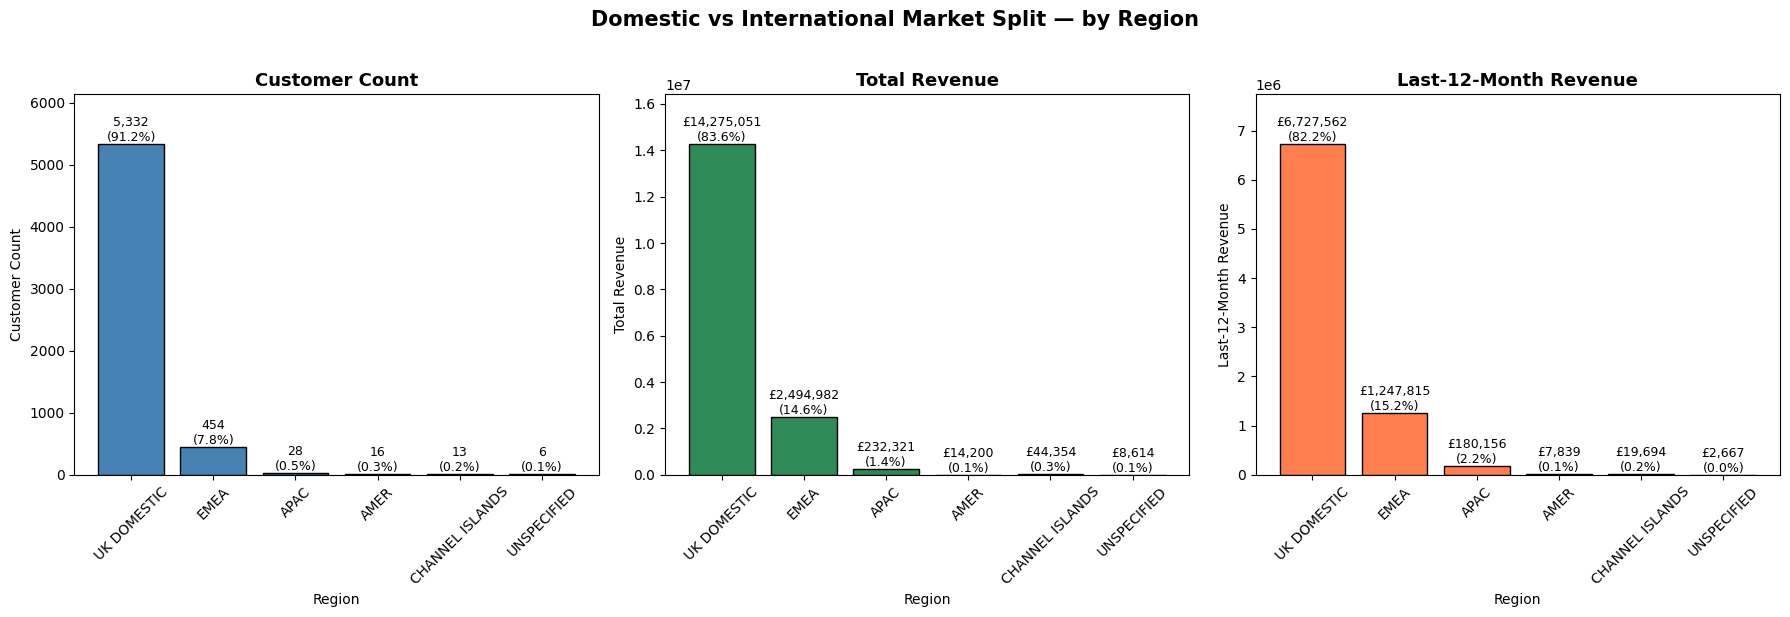

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---- 1. Aggregate by region -------------------------------------------------
region_summary = (
    df_B2B_customer_segmentation
    .groupby('region', dropna=False)
    .agg(
        customer_count=('CustomerHashID', 'nunique'),
        total_revenue =('total_revenue',  'sum'),
        ltm_revenue   =('ltm_revenue',    'sum'),
    )
    .reset_index()
)

# ---- 2. Add percentage columns ---------------------------------------------
region_summary['customer_pct']      = region_summary['customer_count'] / region_summary['customer_count'].sum() * 100
region_summary['total_revenue_pct'] = region_summary['total_revenue']  / region_summary['total_revenue'].sum()  * 100
region_summary['ltm_revenue_pct']   = region_summary['ltm_revenue']    / region_summary['ltm_revenue'].sum()    * 100

# Sort by customer count (largest market first)
region_summary = region_summary.sort_values('customer_count', ascending=False).reset_index(drop=True)

# Append a TOTAL row
totals = pd.DataFrame({
    'region':            ['TOTAL'],
    'customer_count':    [region_summary['customer_count'].sum()],
    'total_revenue':     [region_summary['total_revenue'].sum()],
    'ltm_revenue':       [region_summary['ltm_revenue'].sum()],
    'customer_pct':      [100.0],
    'total_revenue_pct': [100.0],
    'ltm_revenue_pct':   [100.0],
})
summary_table = pd.concat([region_summary, totals], ignore_index=True)[
    ['region', 'customer_count', 'customer_pct',
     'total_revenue', 'total_revenue_pct',
     'ltm_revenue',   'ltm_revenue_pct']
]

# ---- 3. Pretty-print the table ---------------------------------------------
display(
    summary_table.style
        .format({
            'customer_count':    '{:,.0f}',
            'customer_pct':      '{:.2f}%',
            'total_revenue':     '£{:,.2f}',
            'total_revenue_pct': '{:.2f}%',
            'ltm_revenue':       '£{:,.2f}',
            'ltm_revenue_pct':   '{:.2f}%',
        })
        .set_caption("Market split by region — customers, total revenue, last-12-month revenue")
)

# ---- 4. Bar chart -----------------------------------------------------------
plot_df = region_summary.copy()  # exclude the TOTAL row from plotting

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = [
    ('customer_count',  'customer_pct',      'Customer Count',           'steelblue', '{:,}',         ''),
    ('total_revenue',   'total_revenue_pct', 'Total Revenue',            'seagreen',  '£{:,.0f}',     '£'),
    ('ltm_revenue',     'ltm_revenue_pct',   'Last-12-Month Revenue',    'coral',     '£{:,.0f}',     '£'),
]

for ax, (val_col, pct_col, title, color, fmt, prefix) in zip(axes, metrics):
    bars = ax.bar(plot_df['region'], plot_df[val_col], color=color, edgecolor='black')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Region')
    ax.set_ylabel(title)
    ax.tick_params(axis='x', rotation=45)
    ax.margins(y=0.15)  # headroom for labels
    for bar, val, pct in zip(bars, plot_df[val_col], plot_df[pct_col]):
        label = f'{fmt.format(val)}\n({pct:.1f}%)'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), label,
                ha='center', va='bottom', fontsize=9)

plt.suptitle('Domestic vs International Market Split — by Region', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### Key call outs from the above
- UK Domestic purchasers make up 90% of the customer base
- EMEA makes up 8%
- Last 12 month revenue looks about double the circa 2 year total revenue for all regions bar unspecified (bearing in mind the data set is 25 months span not 24 with dec 2011 cutoff at 9th of month missing most of dec data)

**Let's look at Customer Distribution by region versus average of total spend per customer:**

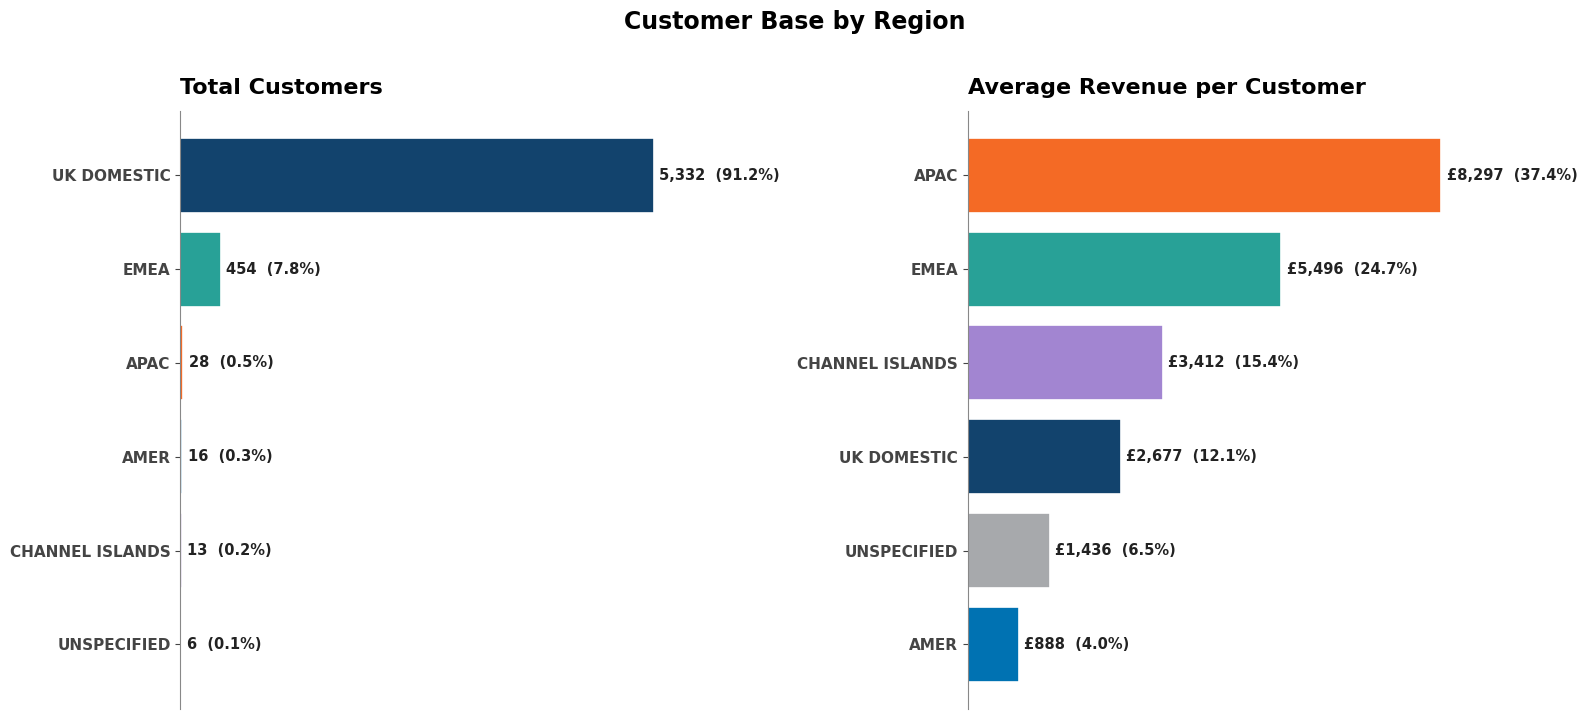

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# ---- 1. Aggregate -----------------------------------------------------------
region_data = (
    df_B2B_customer_segmentation
    .groupby('region', dropna=False)
    .agg(
        customer_count=('CustomerHashID', 'nunique'),
        total_revenue =('total_revenue',  'sum'),
    )
    .reset_index()
)
region_data['customer_pct']           = region_data['customer_count'] / region_data['customer_count'].sum() * 100
region_data['avg_spend_per_customer'] = region_data['total_revenue']  / region_data['customer_count']
region_data['avg_spend_pct']          = region_data['avg_spend_per_customer']  / region_data['avg_spend_per_customer'].sum() * 100

# ---- 2. Fixed colour per region (consistent across BOTH panels) -------------
palette = {
    'UK DOMESTIC':     '#12436D',  # Dark Blue
    'EMEA':            '#28A197',  # Turquoise
    'APAC':            '#F46A25',  # Orange
    'AMER':            '#0072B2',  # Standard Blue
    'CHANNEL ISLANDS': '#A285D1',  # Light Purple
    'UNSPECIFIED':     '#A7A9AC',  # Light Grey
}
region_data['colour'] = region_data['region'].map(lambda r: palette.get(r, '#607D8B'))

# Each panel sorted independently — ascending=True puts the largest value at the TOP of a horizontal bar chart
left_df  = region_data.sort_values('customer_count',         ascending=True)
right_df = region_data.sort_values('avg_spend_per_customer', ascending=True)

# ---- 3. Plot ----------------------------------------------------------------
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Customer Base by Region',
             fontsize=17, fontweight='bold', y=1.02)

def style_axis(ax, xfmt):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False) 
    ax.spines['left'].set_color('#888888')
    ax.spines['bottom'].set_color('#888888')
    # ax.grid(axis='x', linestyle=':', alpha=0.5)
    # ax.grid(False)
    ax.set_axisbelow(True)
    ax.tick_params(colors='#444444')
    ax.tick_params(axis='x', bottom=False, labelbottom=False)  
    ax.xaxis.set_major_formatter(plt.FuncFormatter(xfmt))
    
# LEFT — customer volume
bars_l = ax_l.barh(left_df['region'], left_df['customer_count'],
                   color=left_df['colour'], edgecolor='white', linewidth=1.2)
ax_l.set_title('Total Customers', fontsize=16, fontweight='bold', pad=12, loc='left')
# ax_l.set_xlabel('Number of Customers', fontsize=11)
ax_l.set_xlim(0, left_df['customer_count'].max() * 1.22)
style_axis(ax_l, lambda x, _: f'{int(x):,}')
for bar, cnt, pct in zip(bars_l, left_df['customer_count'], left_df['customer_pct']):
    ax_l.text(bar.get_width() + left_df['customer_count'].max() * 0.012,
              bar.get_y() + bar.get_height()/2,
              f'{cnt:,}  ({pct:.1f}%)',
              va='center', ha='left', fontsize=10.5, fontweight='bold', color='#222222')

# RIGHT — average revenue per customer
bars_r = ax_r.barh(right_df['region'], right_df['avg_spend_per_customer'],
                   color=right_df['colour'], edgecolor='white', linewidth=1.2)
ax_r.set_title('Average Revenue per Customer', fontsize=16, fontweight='bold', pad=12, loc='left')
# ax_r.set_xlabel('Average Revenue per Customer (£)', fontsize=11)
ax_r.set_xlim(0, right_df['avg_spend_per_customer'].max() * 1.22)
style_axis(ax_r, lambda x, _: f'£{int(x):,}')
# for bar, val in zip(bars_r, right_df['avg_spend_per_customer']):
#     ax_r.text(bar.get_width() + right_df['avg_spend_per_customer'].max() * 0.012,
#               bar.get_y() + bar.get_height()/2,
#               f'£{val:,.0f}',
#               va='center', ha='left', fontsize=10.5, fontweight='bold', color='#222222')
    
for bar, val, pct in zip(bars_r,
                         right_df['avg_spend_per_customer'],
                         right_df['avg_spend_pct']):
    ax_r.text(bar.get_width() + right_df['avg_spend_per_customer'].max() * 0.012,
              bar.get_y() + bar.get_height()/2,
              f'£{val:,.0f}  ({pct:.1f}%)',
              va='center', ha='left', fontsize=10.5, fontweight='bold', color='#222222')

plt.setp(ax_l.get_yticklabels(), fontsize=11, fontweight='bold')
plt.setp(ax_r.get_yticklabels(), fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

---
#### Key Graph - 1
- UK Domestic makes up 90% of the customer base and 83% of total revenue with EMEA making up 8% share and 14% total revenue
- In terms of average spend, APAC and EMEA make up a combined 62% of the spend per customer with APAC on £8.2k versus £2.7k UK Domestic

*NB this is a product only view which excludes returns, re-keys, postage fees, additional charges and such like.*


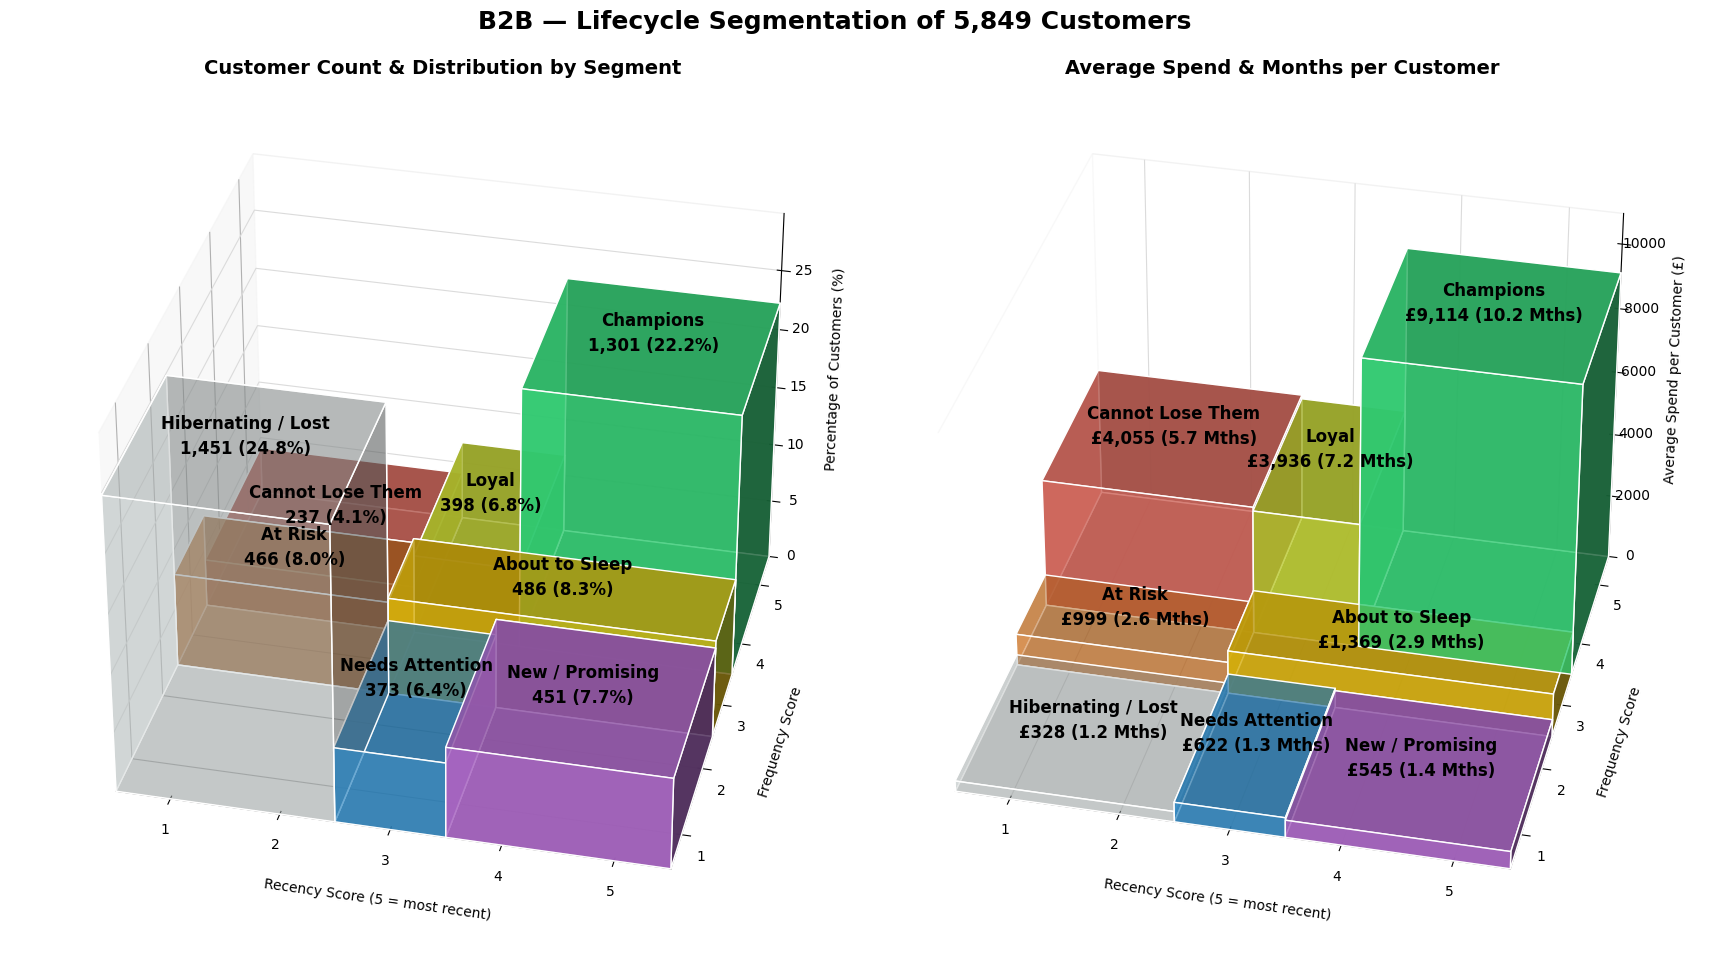

In [101]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# ---- 1. Aggregations -------------------------------------------------------
seg_counts      = df_B2B_customer_segmentation['lifecycle_segment'].value_counts()
seg_avg_spend   = df_B2B_customer_segmentation.groupby('lifecycle_segment')['total_revenue'].mean()
total_customers = len(df_B2B_customer_segmentation)
seg_active_mths = df_B2B_customer_segmentation.groupby('lifecycle_segment')['n_active_months'].mean()

# ---- 2. Colour / alpha / layout maps (unchanged) ---------------------------
colour_map = {
    'Champions':          '#36e47fff',
    'Loyal':              "#d3e436ff",
    'Cannot Lose Them':   "#e76f62",
    'At Risk':            '#e67e22',
    'Needs Attention':    '#3498db',
    'About to Sleep':     '#f1c40f',
    'Hibernating / Lost': "#ced7d7",
    'New / Promising':    '#bd72da',
    'Frequent Low-Spend': '#9b59b6',
}

alpha_map = {
    'Hibernating / Lost':     0.35,
    'At Risk':                0.50,
    'About to Sleep':         0.80,
    'Needs Attention':        0.70,
    'New / Promising':        0.85,
    'Loyal High-Value':       0.80,
    'Champions High-Value':   0.50,
    'Cannot Lose High-Value': 0.90,
}

segment_boxes = {
    'Cannot Lose Them':   (0, 3, 2, 2),
    'Loyal':              (2, 3, 1, 2),
    'Champions':          (3, 3, 2, 2),
    'At Risk':            (0, 2, 2, 1),
    'About to Sleep':     (2, 2, 3, 1),
    'Hibernating / Lost': (0, 0, 2, 2),
    'Needs Attention':    (2, 0, 1, 2),
    'New / Promising':    (3, 0, 2, 2),
}

# ---- 3. Helper: draw one 3D RFM chart on a given axis ----------------------
def draw_rfm_3d(ax, metric_dict, label_builder, z_label, title):
    x_pos, y_pos, z_pos = [], [], []
    dx, dy, dz = [], [], []
    colors = []
    max_val = max(metric_dict.values()) if metric_dict else 0

    for seg, (x, y, w, h) in segment_boxes.items():
        val = metric_dict.get(seg, 0)

        x_pos.append(x);  y_pos.append(y);  z_pos.append(0)
        dx.append(w);     dy.append(h);     dz.append(val)

        rgba = mcolors.to_rgba(colour_map.get(seg, '#333333'),
                               alpha_map.get(seg, 0.8))
        colors.append(rgba)

        # Floating label — offset scaled to the metric so it works for % AND £
        ax.text(x + w/2, y + h/2, val + max_val * 0.04,
                label_builder(seg, val),
                ha='center', va='center',
                fontsize=12, fontweight='bold', color='black',
                linespacing=1.5 )

    ax.bar3d(x_pos, y_pos, z_pos, dx, dy, dz,
             color=colors, edgecolor='white', shade=True)

    ax.set_xlim(0, 5);  ax.set_ylim(0, 5)
    ax.set_zlim(0, max_val * 1.20)
    ax.set_xticks([0.5, 1.5, 2.5, 3.5, 4.5])
    ax.set_yticks([0.5, 1.5, 2.5, 3.5, 4.5])
    ax.set_xticklabels(['1', '2', '3', '4', '5'])
    ax.set_yticklabels(['1', '2', '3', '4', '5'])
    ax.set_xlabel('\nRecency Score (5 = most recent)',  fontsize=10, linespacing=3)
    ax.set_ylabel('\nFrequency Score', fontsize=10, linespacing=3)
    ax.set_zlabel(z_label, fontsize=10, labelpad=10)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=0)
    ax.view_init(elev=33, azim=-77)
    # ax.view_init(elev=24, azim=-77)

# ---- 4. Two 3D panels side-by-side -----------------------------------------
fig = plt.figure(figsize=(22, 11))
fig.suptitle(f'B2B — Lifecycle Segmentation of {total_customers:,} Customers',
             fontsize=18, fontweight='bold', y=0.96)

ax_left  = fig.add_subplot(1, 2, 1, projection='3d')
ax_right = fig.add_subplot(1, 2, 2, projection='3d')

# Clean up panes and grid on the left chart
# ax_left.xaxis.pane.fill = False   # side wall gone
ax_left.zaxis.pane.fill = False   # floor gone
ax_left.yaxis.pane.fill = False   # floor gone

# Gridlines 
# ax_left.yaxis._axinfo['grid']['linewidth'] = 0
# ax_left.zaxis._axinfo['grid']['linewidth'] = 0
ax_left.xaxis._axinfo['grid']['linewidth'] = 0

ax_left.xaxis._axinfo['grid']['color'] = "#dbdbdb"
ax_left.zaxis._axinfo['grid']['color'] = '#dbdbdb'

# LEFT — Total customers and percentage
pct_dict = {seg: (seg_counts.get(seg, 0) / total_customers) * 100
            for seg in segment_boxes}
draw_rfm_3d(
    ax_left,
    metric_dict=pct_dict,
    label_builder=lambda seg, v: f"{seg}\n{int(seg_counts.get(seg, 0)):,} ({v:.1f}%)",
    z_label='Percentage of Customers (%)',
    title='Customer Count & Distribution by Segment',
)

# Clean up panes and grid on the right chart
ax_right.xaxis.pane.fill = False   # side wall gone
ax_right.zaxis.pane.fill = False   # floor gone
ax_right.yaxis.pane.fill = False   # floor gone

# Gridlines 
ax_right.yaxis._axinfo['grid']['linewidth'] = 0
ax_right.zaxis._axinfo['grid']['linewidth'] = 0
# ax_right.xaxis._axinfo['grid']['linewidth'] = 0

ax_right.xaxis._axinfo['grid']['color'] = "#dbdbdb"
ax_right.zaxis._axinfo['grid']['color'] = '#dbdbdb'


# RIGHT — average spend per customer
avg_spend_dict = {seg: seg_avg_spend.get(seg, 0) for seg in segment_boxes}
draw_rfm_3d(
    ax_right,
    metric_dict=avg_spend_dict,
    label_builder=lambda seg, v: f"{seg}\n£{v:,.0f} ({seg_active_mths.get(seg, 0):.1f} Mths)",
    z_label='Average Spend per Customer (£)',
    title='Average Spend & Months per Customer',
)

# plt.subplots_adjust(top=0.90, wspace=0.05)
plt.subplots_adjust(top=0.90, wspace=-0.03)
plt.show()

---
#### Key Graph - 2
- UK Domestic makes up 90% of the customer base and 83% of total revenue with EMEA making up 8% share and 14% total revenue
- In terms of average spend, APAC and EMEA make up a combined 62% of the spend per customer with APAC on £8.2k versus £2.7k UK Domestic

*NB this is a product only view which excludes returns, re-keys, postage fees, additional charges and such like.*


In [8]:
import pandas as pd

# 1. Group by lifecycle_segment and calculate total customers and total revenue
summary_table = df_B2B_customer_segmentation.groupby('lifecycle_segment').agg(
    Total_Customers=('CustomerHashID', 'nunique'), # Count unique customers
    Average_Active_Mths=('n_active_months', 'mean'), # Average of active months
    Total_Revenue=('total_revenue', 'sum')         # Sum the total revenue
).reset_index()

# 2. Calculate Total Revenue / Total Customers
summary_table['Revenue_per_Customer'] = summary_table['Total_Revenue'] / summary_table['Total_Customers']

# 3. Rename columns to match your exact request
summary_table.columns = ['Lifecycle Segment', 'Total Customers', 'Average Active Months', 'Total Revenue Spend', 'Total Revenue / Customers']

# Optional: Sort the table by Total Revenue (Highest to Lowest)
summary_table = summary_table.sort_values(by='Total Revenue Spend', ascending=False)

# 4. Display the table with nice formatting (commas and currency) for Jupyter Notebook
summary_table.style.format({
    'Total Customers': '{:,.0f}',
    'Average Active Months': '{:,.1f}',
    'Total Revenue Spend': '£{:,.2f}',
    'Total Revenue / Customers': '£{:,.2f}'
})

,Lifecycle Segment,Total Customers,Average Active Months,Total Revenue Spend,Total Revenue / Customers
4,Champions,"1,301",10.2,"£11,856,909.73","£9,113.69"
9,Loyal,398,7.2,"£1,566,464.82","£3,935.84"
3,Cannot Lose Them,237,5.7,"£960,975.75","£4,054.75"
0,About to Sleep,486,2.9,"£665,379.69","£1,369.09"
7,Hibernating / Lost,"1,451",1.2,"£476,514.99",£328.40
1,At Risk,466,2.6,"£465,467.81",£998.86
12,New / Promising,451,1.4,"£245,601.57",£544.57
11,Needs Attention,373,1.3,"£232,104.54",£622.26
8,Lost High-Value,65,1.5,"£166,670.66","£2,564.16"
5,Champions Lower-Value,160,4.5,"£149,566.44",£934.79


In [9]:
df_B2B_customer_segmentation[df_B2B_customer_segmentation['lifecycle_segment'] == 'Hibernating / Lost']['n_invoices'].describe()

count    1451.000000
mean        1.239145
std         0.426709
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         2.000000
Name: n_invoices, dtype: float64